Part 4 — Python/Pandas Cleaning, Analysis & Cross-Validation

This notebook loads the raw BigBasket order data, cleans the data using Pandas, analyzes revenue and suppliers, creates charts using Matplotlib, and compares the results with the SQL analysis from Part 1.

In [ ]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders data:")
print(orders.head())

print("\nProducts data:")
print(products.head())


Orders data:
   order_id  order_date customer_name       city              category  \
0         1  2026-03-09           Dev       Pune    Snacks & Beverages   
1         2  2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3  2026-06-30          Yash  Bengaluru  Household Essentials   
3         4  2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5  2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  
0          13         5       175.0          UPI  Delivered     5.0  
1          15         1        60.0   Debit Card  Delivered     5.0  
2          25         2       150.0          UPI  Delivered     2.0  
3          11         1        30.0          UPI  Delivered     4.0  
4          14         2       220.0   Debit Card  Delivered     3.0  

Products data:
   product_id   product_name             category             supplier  \
0           1     Banana 1kg  Fr

In [ ]:
print("Orders information:")
orders.info()

print("\nOrders description:")
print(orders.describe())

print("\nOrder status count:")
print(orders["status"].value_counts())


Orders information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Orders description:
         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.082005
std    144.594139 

Initial Data Inspection

The raw orders data has more than 500 rows, which suggests that there are duplicate orders. Some city and category values have different casing or extra spaces. There are also missing values in amount_inr. Some order amounts look unusually large and may be outliers. The rating column also has missing values, but these are expected for Cancelled and Pending orders because only Delivered orders receive a rating.


In [ ]:
print("Rows before removing duplicates:", len(orders))

duplicates = orders.duplicated(subset="order_id").sum()
print("Duplicate rows:", duplicates)

orders = orders.drop_duplicates(subset="order_id", keep="first")

print("Rows after removing duplicates:", len(orders))


Rows before removing duplicates: 508
Duplicate rows: 8
Rows after removing duplicates: 500


Duplicate Removal

Duplicate rows were identified using order_id. The duplicate rows were removed while keeping the first occurrence. After removing the duplicates, the dataset contains exactly 500 rows.

In [ ]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("Cities:")
print(orders["city"].unique())

print("\nCategories:")
print(orders["category"].unique())


Cities:
['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']

Categories:
['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


Casing and Whitespace

The city and category columns were cleaned using str.strip() and str.title(). After cleaning, there are exactly 4 distinct cities and 6 distinct categories. The cleaned values match the canonical values used in the earlier parts of the project.

In [ ]:
print("Missing amount_inr values:")
print(orders["amount_inr"].isna().sum())

print("\nMissing rating values:")
print(orders["rating"].isna().sum())


Missing amount_inr values:
10

Missing rating values:
66


Missing Value Handling

The missing amount_inr values will not be replaced with zero or an average value. These rows will be excluded from revenue calculations because the missing revenue amount is unknown.

The missing values in rating are left unchanged. Cancelled and Pending orders do not receive ratings, so these null values are expected and are not treated as a data-quality problem.

In [ ]:
delivered_orders = orders[
    (orders["status"] == "Delivered") &
    (orders["amount_inr"].notna())
]

q1 = delivered_orders["amount_inr"].quantile(0.25)
q3 = delivered_orders["amount_inr"].quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)


Q1: 90.0
Q3: 275.0


In [ ]:
iqr = q3 - q1
upper_fence = q3 + (1.5 * iqr)

print("IQR:", iqr)
print("Upper fence:", upper_fence)


IQR: 185.0
Upper fence: 552.5


In [ ]:
outliers = delivered_orders[
    delivered_orders["amount_inr"] > upper_fence
]

print("Number of outliers:", len(outliers))


Number of outliers: 16


In [ ]:
orders["amount_inr"] = orders["amount_inr"].clip(upper=upper_fence)

print("Outliers were capped at:", upper_fence)


Outliers were capped at: 552.5


Outlier Detection and Capping

I used the IQR method on Delivered orders with non-null amount_inr values. Q1 was 90.0 and Q3 was 275.0, giving an IQR of 185.0. The upper fence was 552.5. There were 16 values above the upper fence. These values were capped at 552.5 using the clip() method instead of being removed.

In [ ]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.month
orders["month_name"] = orders["order_date"].dt.month_name()

orders["revenue_per_unit"] = orders["amount_inr"] / orders["quantity"]

orders["is_delivered"] = orders["status"] == "Delivered"

print(orders.head())


   order_id order_date customer_name       city              category  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered  
0      March              35.0          True 

In [ ]:
delivered = orders[orders["status"] == "Delivered"]

category_revenue = delivered.groupby("category")["amount_inr"].sum()

print("Revenue by category:")
print(category_revenue)

print("\nTop category:")
print(category_revenue.idxmax())


Revenue by category:
category
Bakery                  14975.0
Dairy & Eggs            13675.0
Fruits & Vegetables      9170.0
Household Essentials    20910.0
Personal Care           14594.5
Snacks & Beverages      11312.5
Name: amount_inr, dtype: float64

Top category:
Household Essentials


In [12]:
merged_data = pd.merge(
    orders,
    products,
    on="product_id",
    how="left"
)

print(merged_data.head())


   order_id order_date customer_name       city            category_x  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered         product_name  \
0      March           

In [13]:
delivered_data = merged_data[
    merged_data["status"] == "Delivered"
]

supplier_revenue = delivered_data.groupby("supplier")["amount_inr"].sum()

print("Revenue by supplier:")
print(supplier_revenue)

print("\nTop supplier:")
print(supplier_revenue.idxmax())


Revenue by supplier:
supplier
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
CountryEggs Farms          2965.0
DairyBest Ltd             10710.0
FreshFarms Co              5490.0
GreenValley Traders        3680.0
HomeEssentials Traders    20910.0
SnackHub India             7737.5
Name: amount_inr, dtype: float64

Top supplier:
HomeEssentials Traders


In [14]:
merged_data = pd.merge(
    orders,
    products,
    on="product_id",
    how="left"
)

print(merged_data.head())


   order_id order_date customer_name       city            category_x  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered         product_name  \
0      March           

In [15]:
delivered_data = merged_data[merged_data["status"] == "Delivered"]

supplier_revenue = delivered_data.groupby("supplier")["amount_inr"].sum()

print("Revenue by supplier:")
print(supplier_revenue)

print("\nTop supplier:")
print(supplier_revenue.idxmax())


Revenue by supplier:
supplier
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
CountryEggs Farms          2965.0
DairyBest Ltd             10710.0
FreshFarms Co              5490.0
GreenValley Traders        3680.0
HomeEssentials Traders    20910.0
SnackHub India             7737.5
Name: amount_inr, dtype: float64

Top supplier:
HomeEssentials Traders


Cross-Validation with Part 1

The top category from the cleaned Pandas analysis is Household Essentials. This matches the top category found by the Part 1 SQL diagnostic.

The top supplier from the cleaned Pandas analysis is HomeEssentials Traders. This also matches the top supplier found by the Part 1 SQL diagnostic.

The revenue totals are not expected to match exactly because Part 4 starts with the raw data and applies duplicate removal, missing-value exclusions, and IQR outlier capping. However, the top category and top supplier match the Part 1 findings.

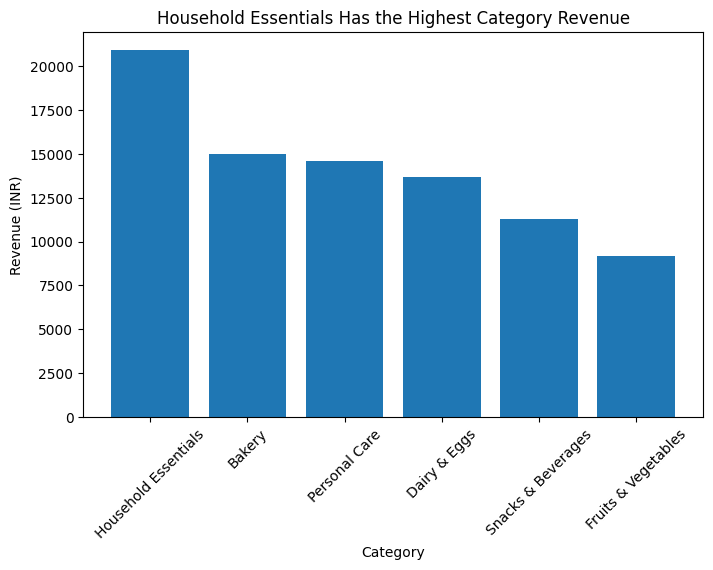

In [16]:
import matplotlib.pyplot as plt

category_revenue = delivered.groupby("category")["amount_inr"].sum()

category_revenue = category_revenue.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(category_revenue.index, category_revenue.values)

plt.title("Household Essentials Has the Highest Category Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.show()


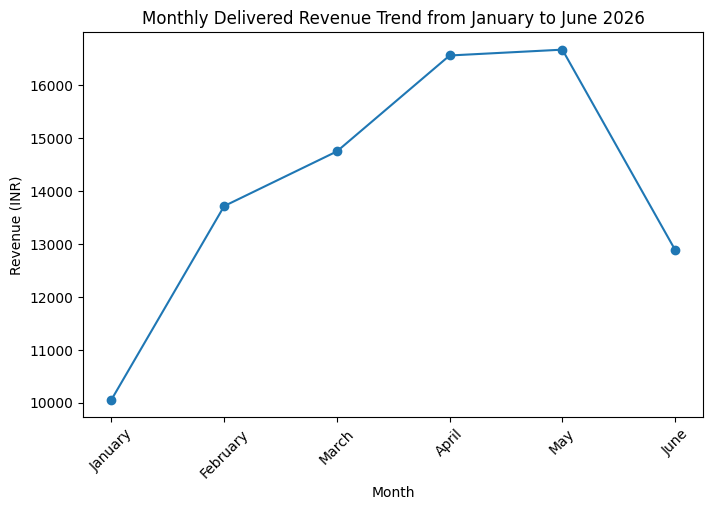

In [17]:
monthly_revenue = delivered.groupby("month_name")["amount_inr"].sum()

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June"
]

monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(8, 5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Delivered Revenue Trend from January to June 2026")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.show()


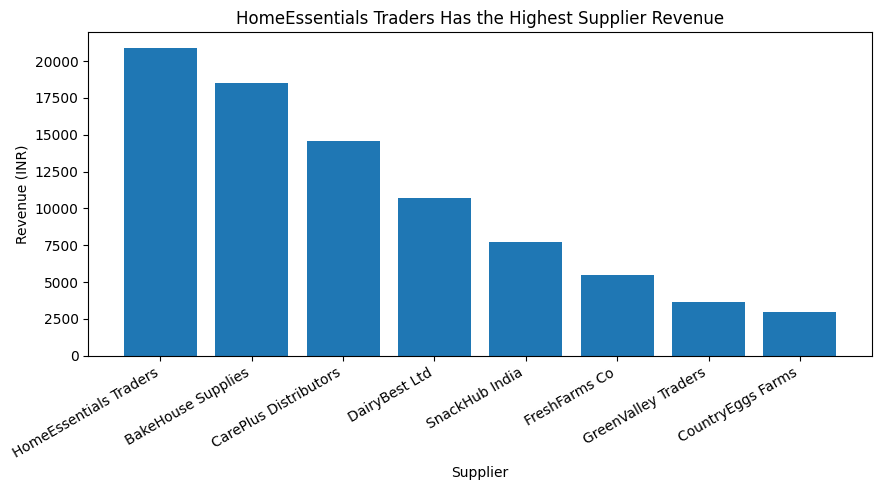

In [19]:
supplier_revenue = delivered_data.groupby("supplier")["amount_inr"].sum()

supplier_revenue = supplier_revenue.sort_values(ascending=False)

plt.figure(figsize=(9, 5))

plt.bar(supplier_revenue.index, supplier_revenue.values)

plt.title("HomeEssentials Traders Has the Highest Supplier Revenue")
plt.xlabel("Supplier")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()



Business Insights
1. Household Essentials is the top revenue category

What: Household Essentials generated INR 20,910 after cleaning and capping, making it the highest-revenue category in the analysis.

Why it matters: It is the strongest category by revenue and also matches the top category found in the Part 1 SQL analysis.

Next step: The category team should review the products and sales activity in Household Essentials to identify which products are contributing most to its revenue.

2. Dairy & Eggs has lower revenue than Household Essentials

What: Dairy & Eggs generated INR 13,675 in delivered revenue, while Household Essentials generated INR 20,910.

Why it matters: There is a difference of INR 7,235 between the two categories, showing a large gap between the highest and lower-performing categories.

Next step: The category team should compare the products and sales activity in Dairy & Eggs with Household Essentials to identify areas that could improve revenue.

3. HomeEssentials Traders is the top supplier

What: HomeEssentials Traders generated the highest supplier revenue in the cleaned and capped data.

Why it matters: The supplier is also the top supplier identified by the Part 1 SQL diagnostic, so the independent Pandas analysis confirms the same leading supplier.

Next step: The category team should review the revenue contribution of HomeEssentials Traders' products and identify which products are driving the supplier's result.

In [22]:
file = open("ai_log.md", "a")

file.write("""

AI-Assisted Prompt #2 — Pandas IQR Outlier Cleaning
Role

Act as a beginner-friendly Python and Pandas tutor.

Context

I am working on a BigBasket sales analysis project in a Jupyter notebook. I have cleaned duplicate orders and fixed the casing and whitespace in my data. I need to identify unusually high amount_inr values for Delivered orders using the IQR method. I need to calculate Q1, Q3, IQR, and the upper fence, and then cap values above the upper fence instead of deleting them.

Task

Help me write simple Pandas code to calculate Q1 and Q3 using .quantile(), calculate the IQR and upper fence, identify the number of outliers, and cap the outliers using .clip().

Constraints

Use beginner-level Pandas code. Do not remove the outliers. Only use Delivered orders with non-null amount_inr values when calculating the IQR. Keep the code simple and easy to understand.

Format

Give the Python code in small, clear steps and briefly explain what each step does.

Verification Performed

I ran the suggested IQR code in my analysis.ipynb notebook and checked the results. The notebook produced Q1 = 90.0, Q3 = 275.0, IQR = 185.0, and an upper fence of 552.5. It identified 16 outliers, and I verified that the values above the upper fence were capped at 552.5 using .clip().
""")
file.close()

print("ai_log.md created")

ai_log.md created
